In [66]:
# 필수 라이브러리 Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_iris, load_wine
import warnings
import platform

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [67]:
df_c = pd.read_csv("../data/olist_customers_dataset.csv")
df_g = pd.read_csv("../data/olist_geolocation_dataset.csv")
df_oi = pd.read_csv("../data/olist_order_items_dataset.csv")
df_op = pd.read_csv("../data/olist_order_payments_dataset.csv")
df_or = pd.read_csv("../data/olist_order_reviews_dataset.csv")
df_o = pd.read_csv("../data/olist_orders_dataset.csv")
df_p = pd.read_csv("../data/olist_products_dataset.csv")
df_s = pd.read_csv("../data/olist_sellers_dataset.csv")

---

In [68]:
df_o.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [69]:
df_o.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

> order_approved_at: 결제 승인 시점<br>
> order_delivered_carrier_date: 택배사 전달 시점<br>
> order_delivered_customer_date: 고객 배송 완료 시점

In [70]:
df_delivered = df_o[df_o['order_status'] == 'delivered']
display(df_delivered.shape)
display(df_delivered.isnull().sum())

(96478, 8)

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

> 배송이 완료된 주문에서도 결측치가 존재 -> 일단 그냥 날리자

In [71]:
df_delivered = df_delivered.dropna()
display(df_delivered.shape)
display(df_delivered.isnull().sum())

(96455, 8)

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [72]:
df_od = df_delivered

---

In [73]:
df_or.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [74]:
df_or.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

---

In [75]:
df_oi.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [76]:
df_oi.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

---

In [77]:
# 날짜형 변환
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    df_od[col] = pd.to_datetime(df_od[col], errors='coerce')

# 배송일수(구매→실배송)
df_od['delivery_days'] = (df_od['order_delivered_customer_date'] - df_od['order_purchase_timestamp']).dt.days

# 배송 지연 여부(실배송 > 예상배송)
df_od['is_delayed'] = df_od['order_delivered_customer_date'] > df_od['order_estimated_delivery_date']

In [78]:
order_review = (
    df_od[['order_id','delivery_days','is_delayed']]
    .merge(df_or[['order_id','review_score']], on='order_id', how='inner')
)

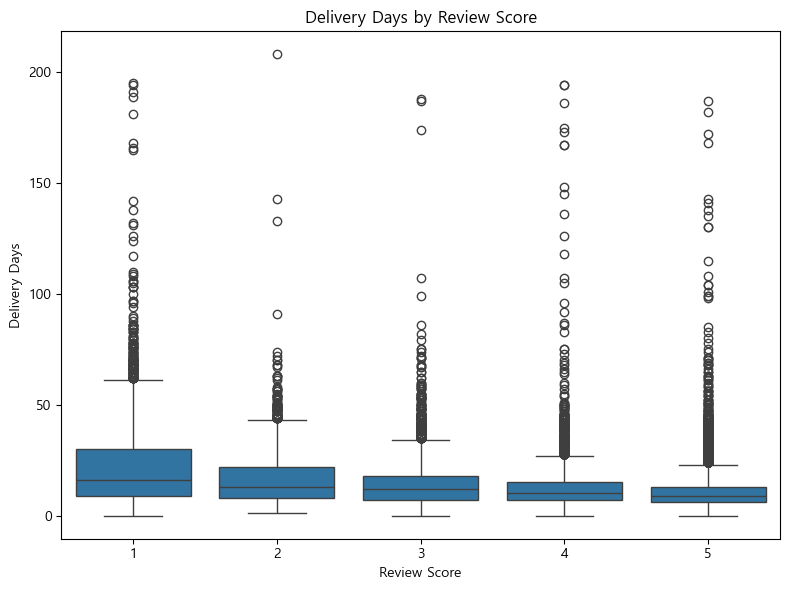

            count   mean  median
is_delayed                      
False       88639  4.294     5.0
True         7699  2.566     2.0


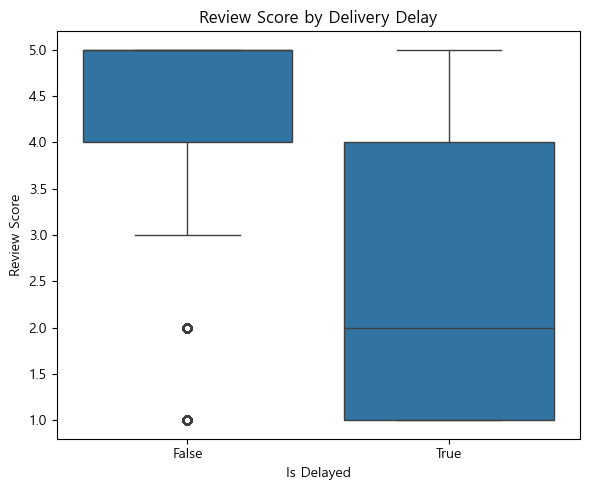

In [79]:
plt.figure(figsize=(8,6))
sns.boxplot(data=order_review, x='review_score', y='delivery_days')
plt.title("Delivery Days by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Days")
plt.tight_layout()
plt.show()

delay_summary = order_review.groupby('is_delayed')['review_score'].agg(['count','mean','median']).round(3)
print(delay_summary)

plt.figure(figsize=(6,5))
sns.boxplot(data=order_review, x='is_delayed', y='review_score')
plt.title("Review Score by Delivery Delay")
plt.xlabel("Is Delayed")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

---

In [80]:
df_review_freight = df_oi.merge(
    df_or[['order_id','review_score']],
    on='order_id'
)

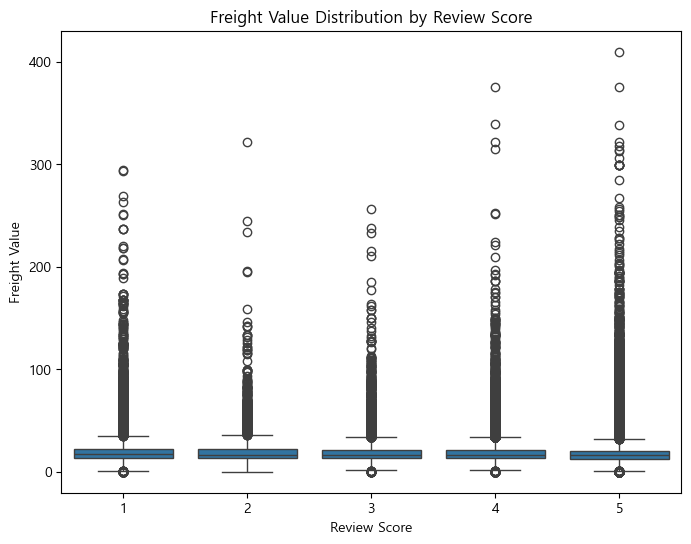

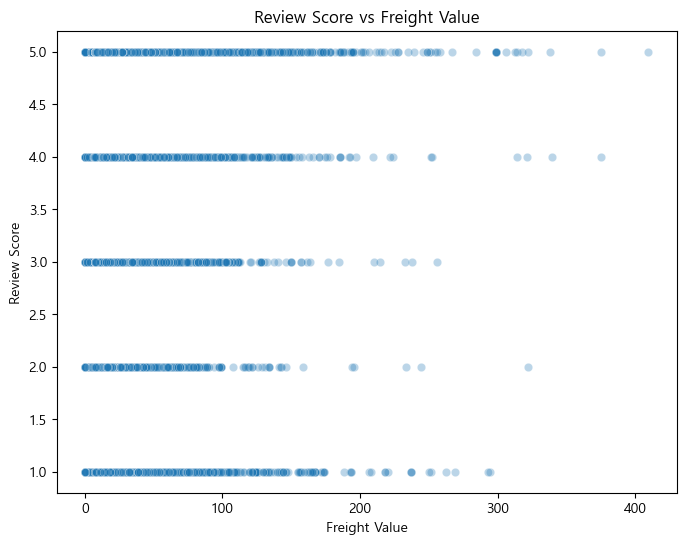

In [81]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_review_freight,
    x='review_score',
    y='freight_value'
)

plt.title("Freight Value Distribution by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Freight Value")

plt.show()

###
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_review_freight,
    x='freight_value',
    y='review_score',
    alpha=0.3
)

plt.title("Review Score vs Freight Value")
plt.xlabel("Freight Value")
plt.ylabel("Review Score")

plt.show()

> 두 그래프를 봤을 땐 단순 배송비가 리뷰점수와 큰 연관성은 없어보임

In [91]:
# df_review_freight['freight_ratio'] = ( 
#     df_review_freight['freight_value'] / 
#     (df_review_freight['price'] + df_review_freight['freight_value'])
# )

# bins = [0,0.05,0.1,0.2,0.3,0.5,1]

# df_review_freight['freight_bin'] = pd.cut( 
#     df_review_freight['freight_ratio'], bins=bins 
# )

# 상품 가격 대비 배송비
df_review_freight['freight_ratio2'] = (
    df_review_freight['freight_value'] /
    df_review_freight['price']
)

# 배송비 비율을 구간으로 나누기
bins = [0, 0.1, 0.3, 0.5, 1, 2, 5, np.inf]
labels = [
    '0~0.1',
    '0.1~0.3',
    '0.3~0.5',
    '0.5~1',
    '1~2',
    '2~5',
    '5~'
]

df_review_freight['freight_bin'] = pd.cut(
    df_review_freight['freight_ratio2'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

ratio_review = df_review_freight.groupby(
    'freight_bin'
)['review_score'].mean()

ratio_review

# (1.0, 2.0] -> 1.0 < ratio ≤ 2.0 

freight_bin
0~0.1      4.069302
0.1~0.3    4.062961
0.3~0.5    3.992389
0.5~1      3.991888
1~2        3.861818
2~5        3.797938
5~         2.341463
Name: review_score, dtype: float64

In [92]:
display(df_review_freight['freight_bin'].value_counts())
display(df_oi['freight_value'].count())
display(df_review_freight['freight_bin'].value_counts().sum())
df_review_freight['freight_bin'].isna().sum()

freight_bin
0.1~0.3    53843
0.3~0.5    22204
0~0.1      17431
0.5~1      14793
1~2         3575
2~5          485
5~            41
Name: count, dtype: int64

np.int64(112650)

np.int64(112372)

np.int64(0)

In [95]:
print("df_oi freight count:", df_oi['freight_value'].count())
print("df_or review count:", df_or['review_score'].count())
print("df_review_freight rows:", len(df_review_freight))
print("freight_bin count:", df_review_freight['freight_bin'].value_counts().sum())
print("freight_bin NaN:", df_review_freight['freight_bin'].isna().sum())

df_oi freight count: 112650
df_or review count: 99224
df_review_freight rows: 112372
freight_bin count: 112372
freight_bin NaN: 0


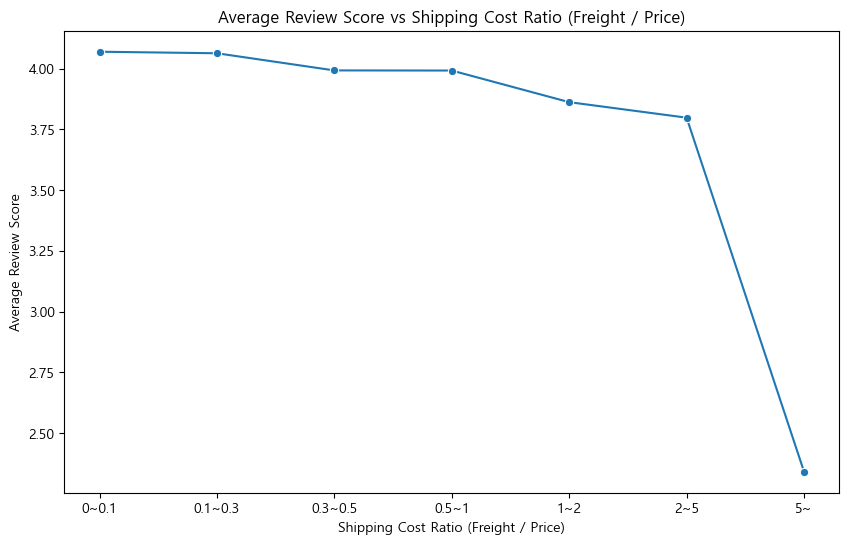

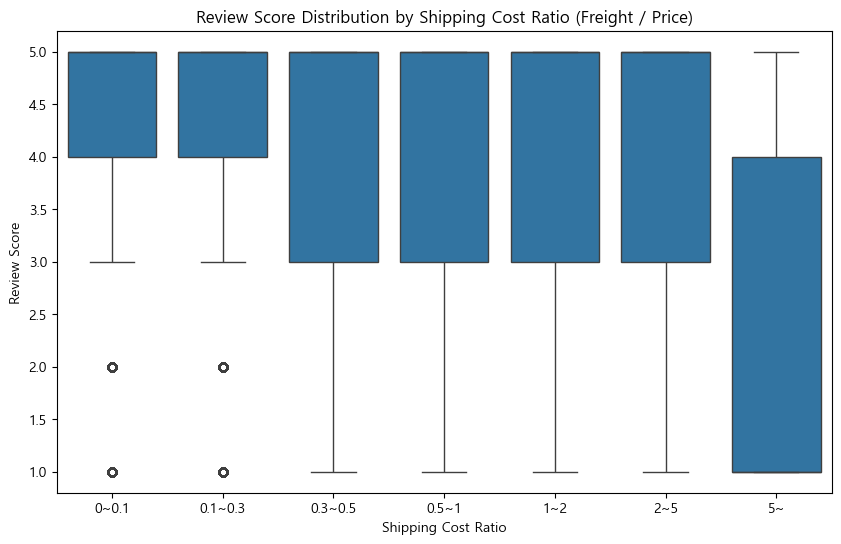

In [93]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=ratio_review.index.astype(str),
    y=ratio_review.values,
    marker='o'
)

plt.title("Average Review Score vs Shipping Cost Ratio (Freight / Price)")
plt.xlabel("Shipping Cost Ratio (Freight / Price)")
plt.ylabel("Average Review Score")

plt.show()

###
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_review_freight,
    x='freight_bin',
    y='review_score'
)

plt.title("Review Score Distribution by Shipping Cost Ratio (Freight / Price)")
plt.xlabel("Shipping Cost Ratio")
plt.ylabel("Review Score")

plt.show()

---

# 여기가 진짜

In [103]:
df_or['review_score'].count()

np.int64(99224)

In [104]:
df_oi['order_id'].count()

np.int64(112650)

In [105]:
df_oi.groupby('order_id').size().mean()

np.float64(1.1417306873695092)

> 한 주문자가 여러 상품을 구매해도 리뷰 점수는 하나만 남기게 되어있다<br>
> 그러나 대부분의 주문은 상품 1개를 주문했으므로 크게 신경쓰지 않아도 될지도?

> 그래서 밑에 코드 1번에서 주문 단위로 상품가격/배송비를 집계해야한다는데..
> 아직 이게 뭔 소리인지 잘 이해가 안된다

대충 이해한 내용으로는<br>
olist 데이터는 여러 상품을 한 번에 구매했을 때, 어떤 상품 때문에 리뷰 점수가 매겨졌는지 알 수 없다고 한다<br>
<br>
한 주문에 여러 상품이 들어갈 수 있는데 이때 리뷰에는 order_id만 있을 뿐 product_id가 없기 때문에 어떤 상품에 리뷰 점수가 매겨졌는지 모르는 것
<br>
그래서
```
order_price_freight = df_oi.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum')
).reset_index()
```
이 코드로 order_id에 들어있는 모든 상품을 묶어서 계산해야 그나마 오류가 적어진다 -> 주문 단위로 분석을 해야한다는 뜻<br>
<br>
한계 발생) olist 데이터셋의 리뷰는 주문 단위로 제공되므로, 특정 상품이나 판매자에 대한 직접적인 평가라고 단정하기는 어렵다<br>
<br>
다행인 부분) ```df_oi.groupby('order_id').size().mean()```<br>
위 코드로 대부분의 주문은 상품을 1개만 구매했음을 볼 수 있어
주문 수 = 주문 리뷰 수로 봐도 큰 오류가 발생하진 않을 것 같다는 점이다


In [110]:
df_oi.groupby('order_id').size().mean()

np.float64(1.1417306873695092)

In [106]:
# 1. 주문 단위로 상품가격 / 배송비 집계
order_price_freight = df_oi.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum')
).reset_index()

# 2. 리뷰와 merge
# 리뷰 1개(order_id 1개)당 한 행이 되도록 맞춤
df_review_freight_order = order_price_freight.merge(
    df_or[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

# 3. 상품 총가격이 0인 경우 제거
df_review_freight_order = df_review_freight_order[
    df_review_freight_order['total_price'] > 0
].copy()

# 4. 배송비 비율 계산
df_review_freight_order['freight_ratio'] = (
    df_review_freight_order['total_freight'] /
    df_review_freight_order['total_price']
)

# 5. 구간 나누기
bins = [0, 0.1, 0.3, 0.5, 1, 2, 5, np.inf]
labels = ['0~0.1', '0.1~0.3', '0.3~0.5', '0.5~1', '1~2', '2~5', '5~']

df_review_freight_order['freight_bin'] = pd.cut(
    df_review_freight_order['freight_ratio'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 6. 확인
print("주문 단위 행 수:", len(df_review_freight_order))
print("리뷰 점수 수:", df_review_freight_order['review_score'].count())
print("배송비 구간 수:", df_review_freight_order['freight_bin'].value_counts().sum())
print("배송비 구간 NaN:", df_review_freight_order['freight_bin'].isna().sum())

# 7. 구간별 평균 리뷰 점수
ratio_review = df_review_freight_order.groupby('freight_bin')['review_score'].mean()
display(ratio_review)

# 8. 구간별 개수
display(df_review_freight_order['freight_bin'].value_counts().sort_index())

주문 단위 행 수: 98465
리뷰 점수 수: 98465
배송비 구간 수: 98465
배송비 구간 NaN: 0


freight_bin
0~0.1      4.136596
0.1~0.3    4.120675
0.3~0.5    4.075107
0.5~1      4.078833
1~2        3.981442
2~5        3.988270
5~         3.384615
Name: review_score, dtype: float64

freight_bin
0~0.1      15630
0.1~0.3    48262
0.3~0.5    18973
0.5~1      12444
1~2         2802
2~5          341
5~            13
Name: count, dtype: int64

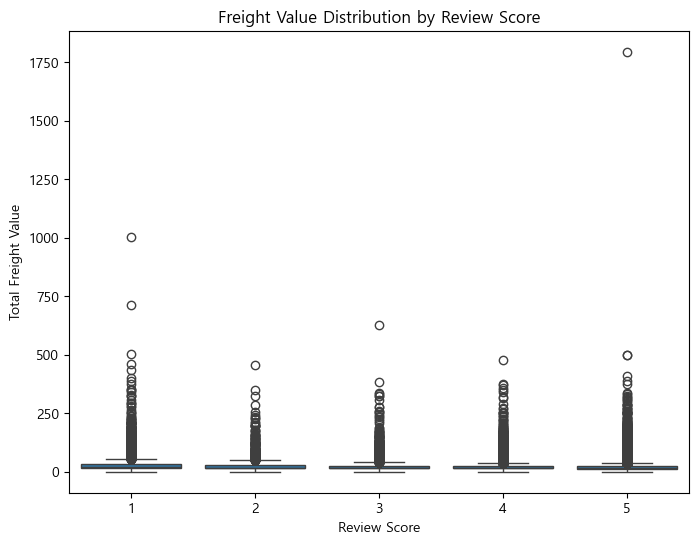

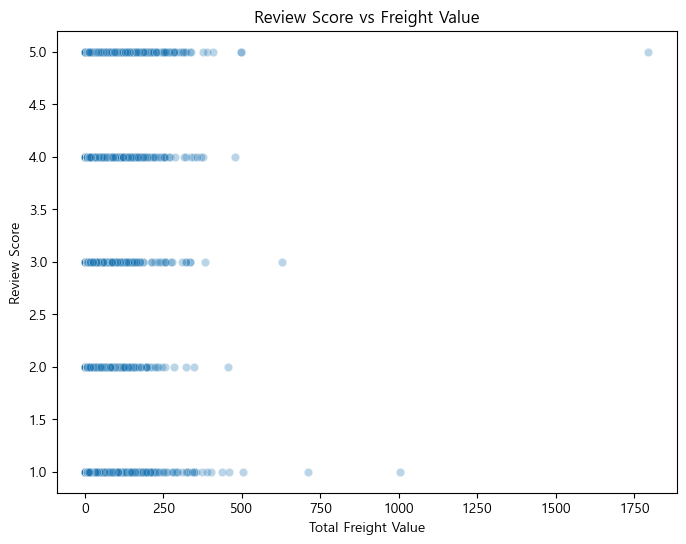

In [107]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_review_freight_order,
    x='review_score',
    y='total_freight'
)

plt.title("Freight Value Distribution by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Total Freight Value")

plt.show()

###

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_review_freight_order,
    x='total_freight',
    y='review_score',
    alpha=0.3
)

plt.title("Review Score vs Freight Value")
plt.xlabel("Total Freight Value")
plt.ylabel("Review Score")

plt.show()

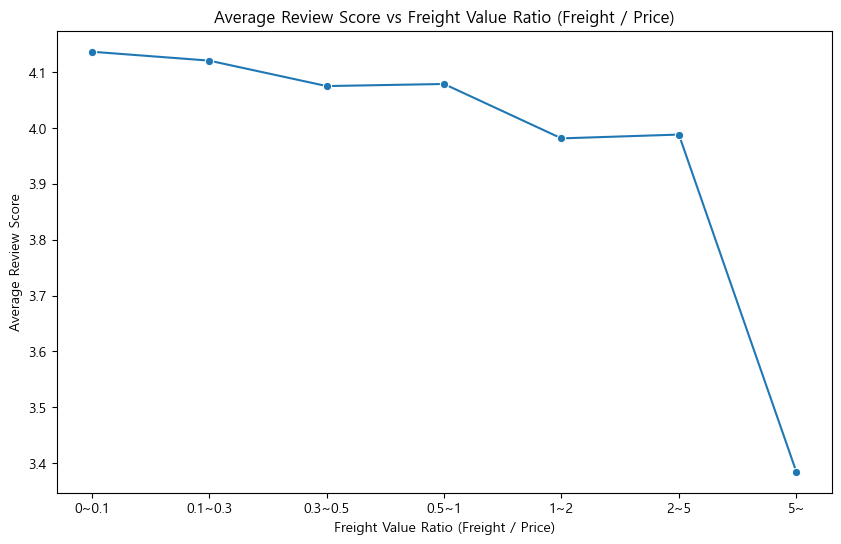

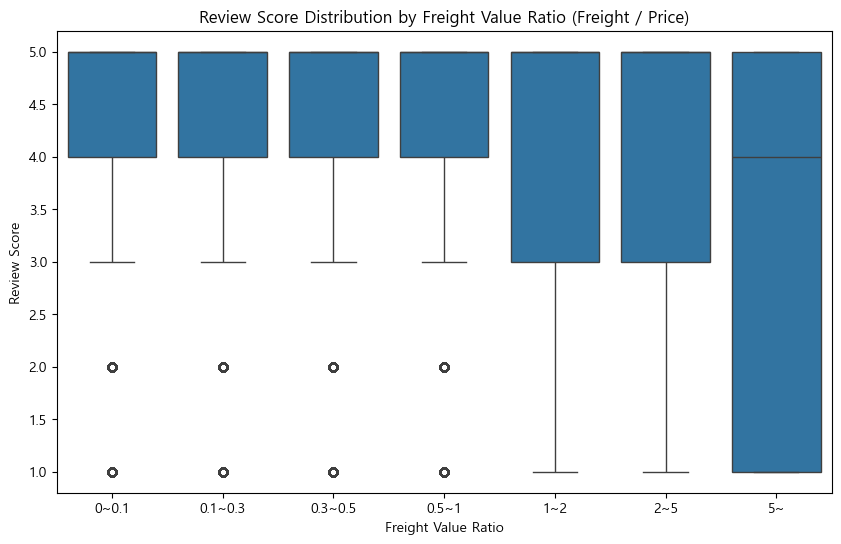

In [111]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=ratio_review.index.astype(str),
    y=ratio_review.values,
    marker='o'
)

plt.title("Average Review Score vs Freight Value Ratio (Freight / Price)")
plt.xlabel("Freight Value Ratio (Freight / Price)")
plt.ylabel("Average Review Score")

plt.show()

###

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_review_freight_order,
    x='freight_bin',
    y='review_score'
)

plt.title("Review Score Distribution by Freight Value Ratio (Freight / Price)")
plt.xlabel("Freight Value Ratio")
plt.ylabel("Review Score")

plt.show()

---

In [112]:
from scipy.stats import spearmanr

corr, p = spearmanr(
    df_review_freight_order['freight_ratio'],
    df_review_freight_order['review_score']
)

print(corr, p)

-0.02599995723565203 3.354772293872099e-16


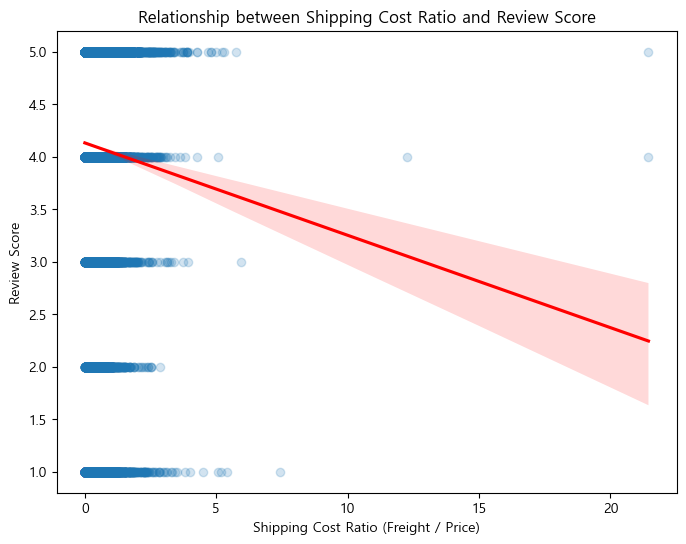

In [113]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_review_freight_order,
    x='freight_ratio',
    y='review_score',
    scatter_kws={'alpha':0.2},
    line_kws={'color':'red'}
)

plt.title("Relationship between Shipping Cost Ratio and Review Score")
plt.xlabel("Shipping Cost Ratio (Freight / Price)")
plt.ylabel("Review Score")

plt.show()

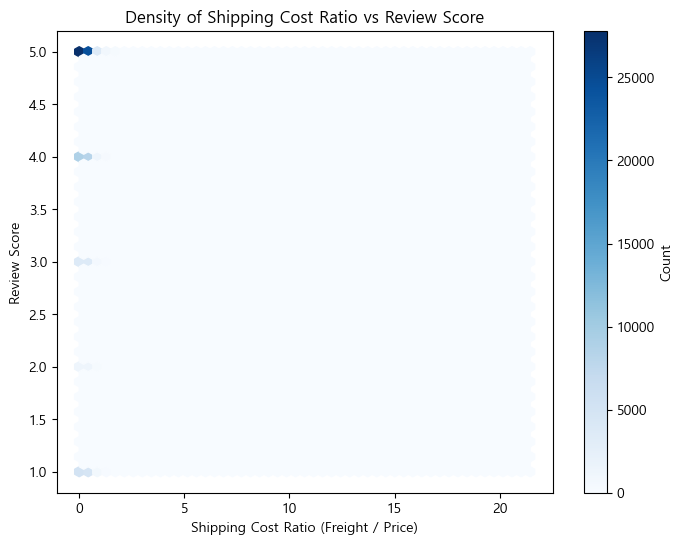

In [115]:
plt.figure(figsize=(8,6))

plt.hexbin(
    df_review_freight_order['freight_ratio'],
    df_review_freight_order['review_score'],
    gridsize=50,
    cmap='Blues'
)

plt.colorbar(label='Count')

plt.title("Density of Shipping Cost Ratio vs Review Score")
plt.xlabel("Shipping Cost Ratio (Freight / Price)")
plt.ylabel("Review Score")

plt.show()

In [116]:
df_ratio5 = df_review_freight_order[
    df_review_freight_order['freight_ratio'] <= 5
]

In [117]:
corr, p = spearmanr(
    df_ratio5['freight_ratio'],
    df_ratio5['review_score']
)

print("Spearman r:", corr)
print("p-value:", p)

Spearman r: -0.025899277482285647
p-value: 4.3754009758098346e-16


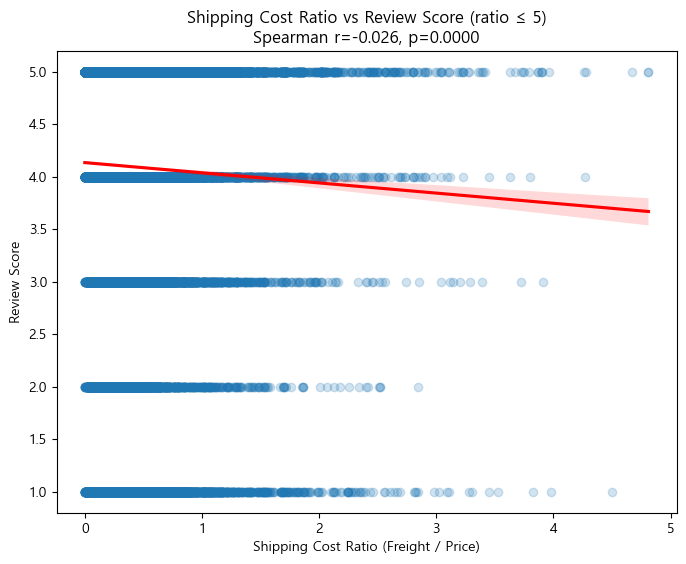

In [118]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_ratio5,
    x='freight_ratio',
    y='review_score',
    scatter_kws={'alpha':0.2},
    line_kws={'color':'red'}
)

plt.title(f"Shipping Cost Ratio vs Review Score (ratio ≤ 5)\nSpearman r={corr:.3f}, p={p:.4f}")
plt.xlabel("Shipping Cost Ratio (Freight / Price)")
plt.ylabel("Review Score")

plt.show()